In [ ]:
# --- IMPORT LIBRARY ---
import tensorflow as tf
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetV2S
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping

from tensorflow.keras.regularizers import l2

In [30]:
# --- 1. SETUP GPU RTX 3050 ---
print("🔍 Memeriksa GPU...")
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"✅ GPU RTX 3050 Terdeteksi! Siap Training.")
        BATCH_SIZE = 4 
    except RuntimeError as e:
        print(e)
else:
    BATCH_SIZE = 8

# --- KONFIGURASI ---
DATA_DIR = "Rice_Leaf_AUG_split"
IMG_SIZE = (224, 224)
EPOCHS = 30  # Bisa ubah ke 50 jika mau lebih lama
START_LR = 0.0001

🔍 Memeriksa GPU...
✅ GPU RTX 3050 Terdeteksi! Siap Training.


In [ ]:
# --- 2. PERSIAPAN DATA ---
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

print("\n📂 Memuat Data Generator...")
if not os.path.exists(DATA_DIR):
    print("❌ Error: Folder dataset tidak ditemukan.")
else:
    # Train Generator
    train_gen = train_datagen.flow_from_directory(
        os.path.join(DATA_DIR, 'train'),
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        shuffle=True
    )

    # Val Generator
    val_gen = val_datagen.flow_from_directory(
        os.path.join(DATA_DIR, 'val'),
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        shuffle=False
    )
    
    # Test Generator (Shuffle False agar urutan prediksi benar)
    test_gen = test_datagen.flow_from_directory(
        os.path.join(DATA_DIR, 'test'),
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        shuffle=False 
    )

    NUM_CLASSES = len(train_gen.class_indices)
    CLASS_NAMES = list(train_gen.class_indices.keys())


📂 Memuat Data Generator...
Found 1797 images belonging to 4 classes.
Found 512 images belonging to 4 classes.
Found 260 images belonging to 4 classes.



📊 Menampilkan Distribusi Data...


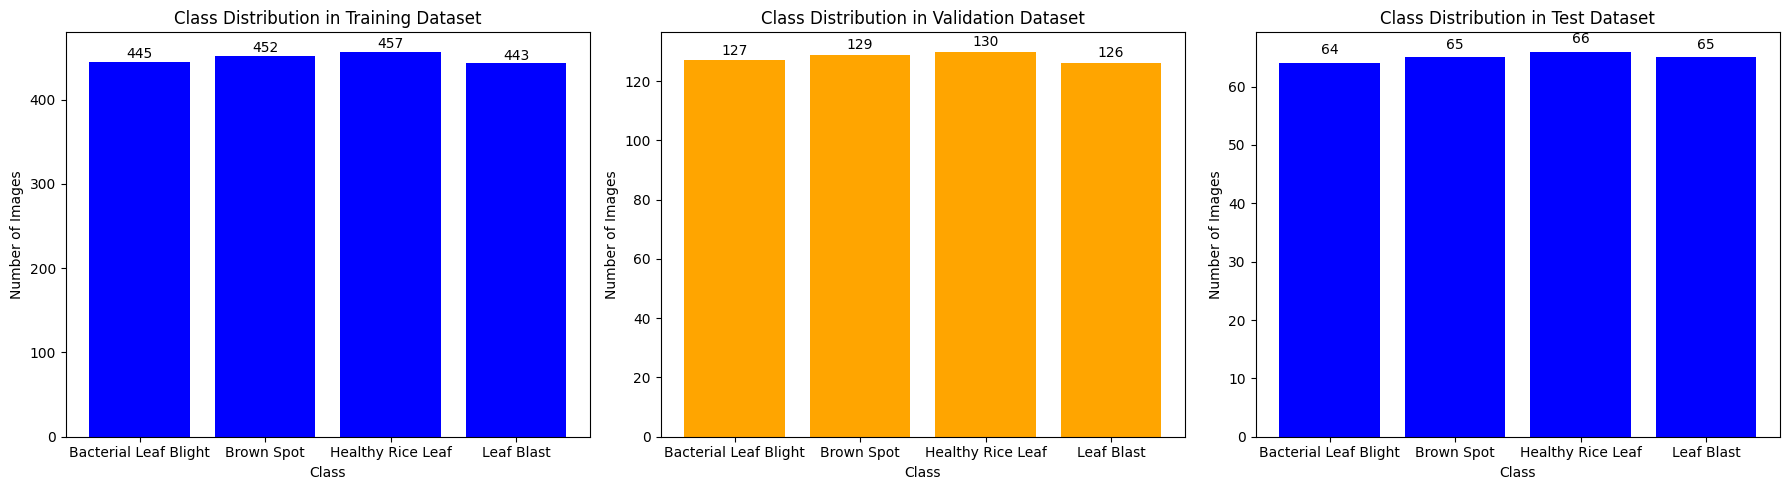

In [32]:
# --- 3. VISUALISASI DISTRIBUSI DATA (SEPERTI CONTOH) ---
def plot_distribution(generator, title, color):
    # Hitung jumlah file per kelas
    class_counts = np.zeros(NUM_CLASSES)
    # Kita iterasi file list generator (lebih cepat daripada loop batch)
    for cls_idx in generator.classes:
        class_counts[cls_idx] += 1
        
    plt.bar(CLASS_NAMES, class_counts, color=color)
    plt.title(title)
    plt.ylabel('Number of Images')
    plt.xlabel('Class')
    plt.xticks(rotation=0) # Biar label tegak
    
    # Tambah angka di atas bar
    for i, count in enumerate(class_counts):
        plt.text(i, count + 1, str(int(count)), ha='center', va='bottom')

if 'train_gen' in locals():
    print("\n📊 Menampilkan Distribusi Data...")
    plt.figure(figsize=(18, 5))
    
    plt.subplot(1, 3, 1)
    plot_distribution(train_gen, 'Class Distribution in Training Dataset', 'blue')
    
    plt.subplot(1, 3, 2)
    plot_distribution(val_gen, 'Class Distribution in Validation Dataset', 'orange')
    
    plt.subplot(1, 3, 3)
    plot_distribution(test_gen, 'Class Distribution in Test Dataset', 'blue') # Bisa ganti warna
    
    plt.tight_layout()
    plt.show()

In [33]:
# --- 4. BUILD MODEL EFFICIENTNETV2-S ---
def build_model():
    print("\n🏗️ Membangun Arsitektur EfficientNetV2-S...")
    base_model = EfficientNetV2S(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
    
    # Fine Tuning: Unfreeze agar model belajar tekstur padi
    base_model.trainable = True 
    
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = BatchNormalization()(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x) 
    predictions = Dense(NUM_CLASSES, activation='softmax')(x)
    
    model = Model(inputs=base_model.input, outputs=predictions)
    model.compile(optimizer=Adam(learning_rate=START_LR),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

In [34]:
# --- 5. TRAINING ---
model = build_model()

# Callbacks
checkpoint = ModelCheckpoint('efficientnetv2s_best.h5', monitor='val_accuracy', save_best_only=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)
early_stop = EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True, verbose=1)

print("\n🚀 Mulai Training...")
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    callbacks=[checkpoint, reduce_lr, early_stop]
)


🏗️ Membangun Arsitektur EfficientNetV2-S...

🚀 Mulai Training...
Epoch 1/30
450/450 [==============================] - ETA: 0s - loss: 1.4377 - accuracy: 0.5036
Epoch 1: val_accuracy improved from -inf to 0.75977, saving model to efficientnetv2s_best.h5
450/450 [==============================] - 86s 156ms/step - loss: 1.4377 - accuracy: 0.5036 - val_loss: 0.6621 - val_accuracy: 0.7598 - lr: 1.0000e-04
Epoch 2/30
450/450 [==============================] - ETA: 0s - loss: 0.9652 - accuracy: 0.6772
Epoch 2: val_accuracy improved from 0.75977 to 0.87305, saving model to efficientnetv2s_best.h5
450/450 [==============================] - 60s 132ms/step - loss: 0.9652 - accuracy: 0.6772 - val_loss: 0.3561 - val_accuracy: 0.8730 - lr: 1.0000e-04
Epoch 3/30
450/450 [==============================] - ETA: 0s - loss: 0.7588 - accuracy: 0.7379
Epoch 3: val_accuracy improved from 0.87305 to 0.89648, saving model to efficientnetv2s_best.h5
450/450 [==============================] - 59s 131ms/step -


📈 Menampilkan Grafik Training...


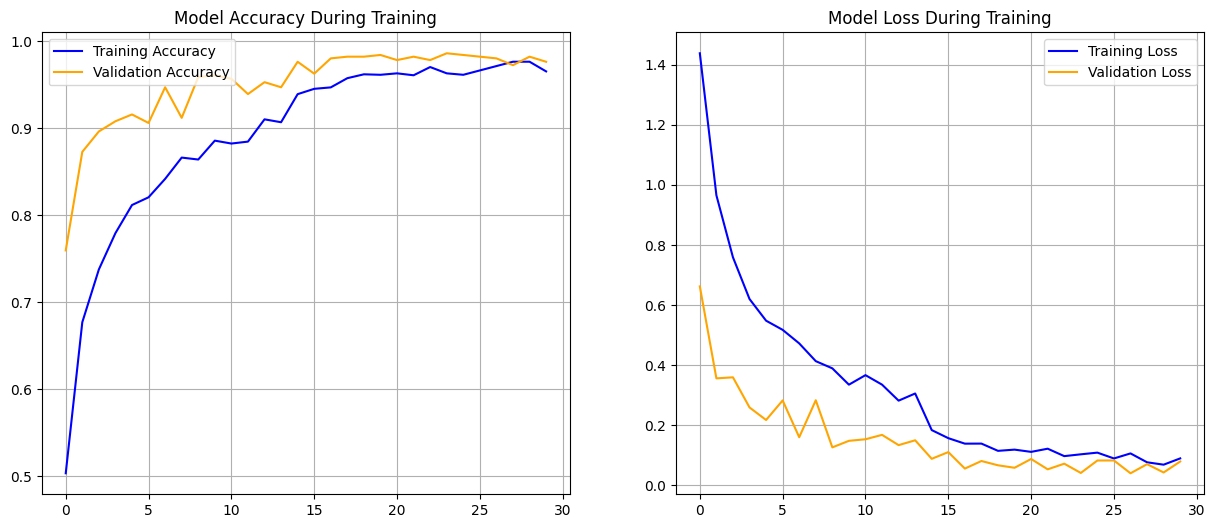

In [35]:
# --- 6. VISUALISASI HISTORY (ACCURACY & LOSS) ---
print("\n📈 Menampilkan Grafik Training...")
acc = history.history['accuracy'] # Kadang key-nya 'accuracy', kadang 'acc' tergantung versi
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(15, 6))

# Grafik Akurasi
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy', color='blue')
plt.plot(epochs_range, val_acc, label='Validation Accuracy', color='orange')
plt.title('Model Accuracy During Training')
plt.legend(loc='upper left')
plt.grid(True)

# Grafik Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss', color='blue')
plt.plot(epochs_range, val_loss, label='Validation Loss', color='orange')
plt.title('Model Loss During Training')
plt.legend(loc='upper right')
plt.grid(True)

plt.show()


🔍 Evaluasi Detail pada Data Test...
65/65 [==============================] - 3s 44ms/step


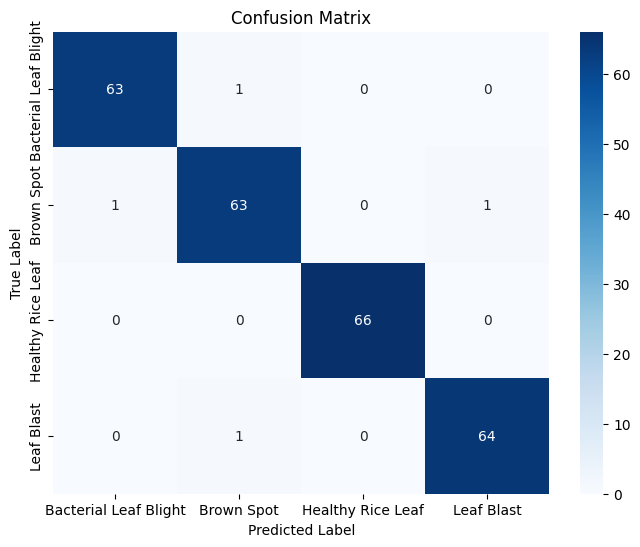


📄 Classification Report:
                       precision    recall  f1-score   support

Bacterial Leaf Blight       0.98      0.98      0.98        64
           Brown Spot       0.97      0.97      0.97        65
    Healthy Rice Leaf       1.00      1.00      1.00        66
           Leaf Blast       0.98      0.98      0.98        65

             accuracy                           0.98       260
            macro avg       0.98      0.98      0.98       260
         weighted avg       0.98      0.98      0.98       260


🖼️ Sampel Prediksi dengan Score...
Found 260 images belonging to 4 classes.
1/1 [==============================] - 0s 33ms/step


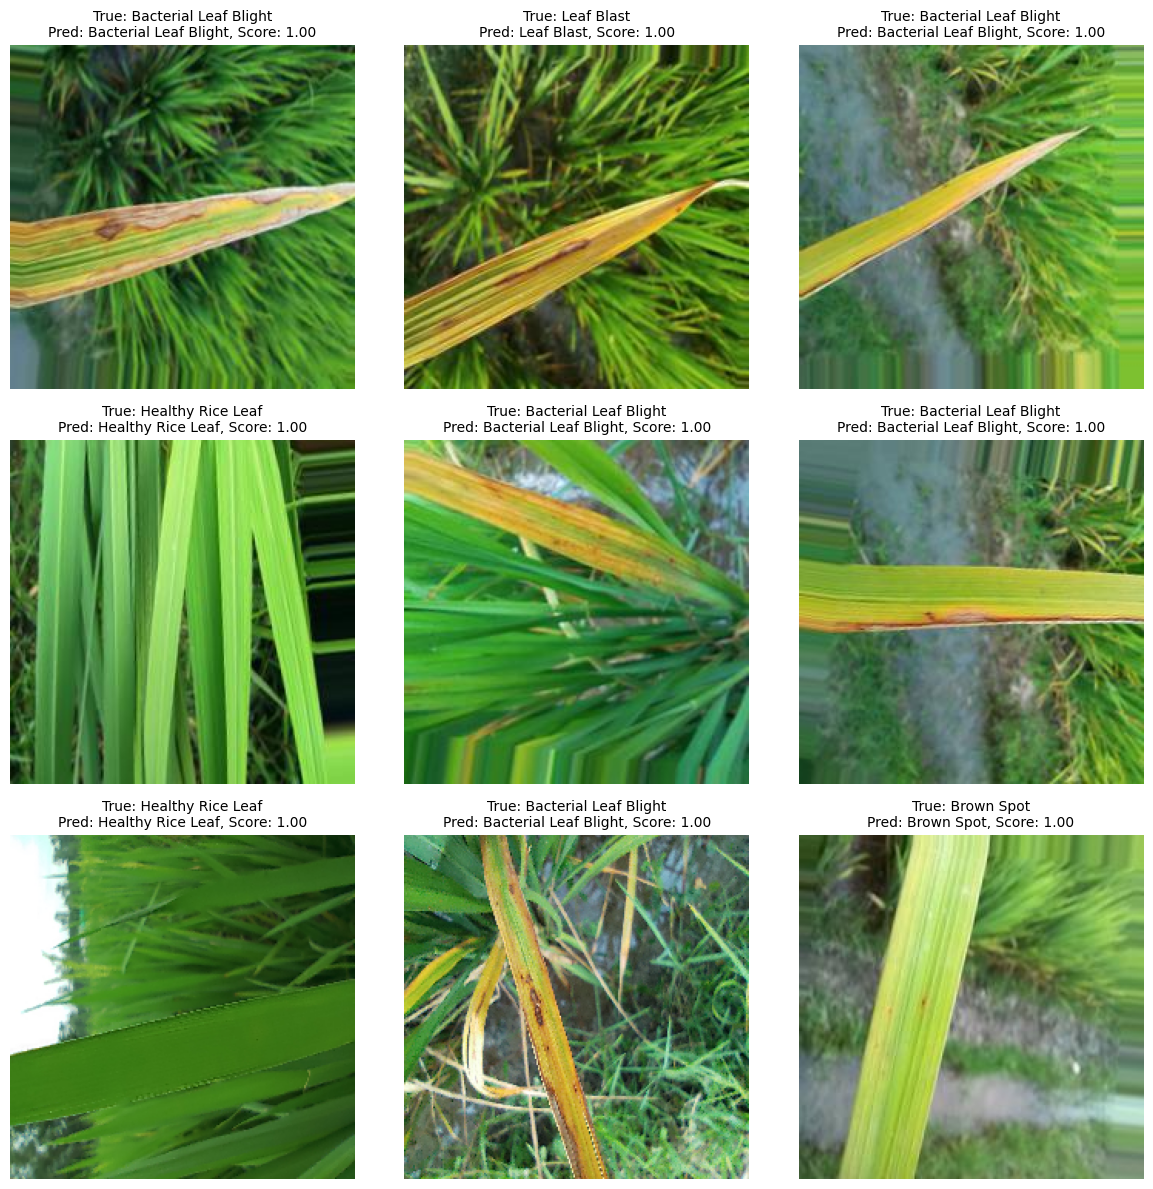


✅ Semua proses selesai! Model tersimpan sebagai 'efficientnetv2s_best.h5'


In [37]:
# --- 7. EVALUASI & CONFUSION MATRIX ---
print("\n🔍 Evaluasi Detail pada Data Test...")

# Prediksi
predictions = model.predict(test_gen)
y_pred = np.argmax(predictions, axis=1)
y_true = test_gen.classes

# Confusion Matrix Heatmap
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# Classification Report
print("\n📄 Classification Report:")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

# --- 8. SAMPEL PREDIKSI (DENGAN SCORE) ---
print("\n🖼️ Sampel Prediksi dengan Score...")

# Ambil 1 batch (9 gambar) dari test set secara acak
sample_gen = test_datagen.flow_from_directory(
    os.path.join(DATA_DIR, 'test'),
    target_size=IMG_SIZE,
    batch_size=9,
    class_mode='categorical',
    shuffle=True # Acak biar yang tampil beda-beda
)

images, labels = next(sample_gen)
preds = model.predict(images)
pred_labels = np.argmax(preds, axis=1)
true_labels = np.argmax(labels, axis=1)

plt.figure(figsize=(12, 12))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(images[i])
    
    # Ambil nama kelas dan score probabilitas tertinggi
    true_name = CLASS_NAMES[true_labels[i]]
    pred_name = CLASS_NAMES[pred_labels[i]]
    score = np.max(preds[i])
    
    # Judul format: "True: X, Pred: Y, Score: 0.99"
    title_color = 'black' if true_name == pred_name else 'red'
    plt.title(f"True: {true_name}\nPred: {pred_name}, Score: {score:.2f}", 
              color=title_color, fontsize=10)
    plt.axis('off')

plt.tight_layout()
plt.show()

print("\n✅ Semua proses selesai! Model tersimpan sebagai 'efficientnetv2s_best.h5'")